In [1]:
# load the K562 lentiMPRA single-seq ISM (saturation-mutagenesis) maps for one seed
# gradient-corrected (mean-centered across channels) — analog of hypothetical DeepLIFT
import numpy as np, pandas as pd
import h5py
import matplotlib.pyplot as plt
import logomaker
from scipy.special import logsumexp

seam_dir = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
peak = "peak84030"               # top K562 lentiMPRA seed (seam_seeds.csv)

lib    = "200k"                           # <-- switch library size here: "100k" or "200k"
suffix = {"100k": "", "200k": "_200k"}[lib]

with h5py.File(f"{seam_dir}/ism{suffix}/{peak}.h5") as f:
    attributions = f["ism_centered"][:]   # (N, 200, 4) ISM, mean-centered across channels
    predictions  = f["predictions"][:]    # (N,) self-prediction of each mutant

with h5py.File(f"{seam_dir}/mutagenesis_lib{suffix}/{peak}.h5") as f:
    wt_sequence = f["wt_sequence"][:]     # (230, 4) with 15bp adapters

wt_onehot = wt_sequence[15:215]           # variable region matches attributions axis
wt_attr   = attributions[0]               # WT attribution map (index 0)
print(f"[{lib}] {attributions.shape[0]:,} attribution maps  |  shape per map: {attributions.shape[1:]}")

[200k] 200,000 attribution maps  |  shape per map: (200, 4)


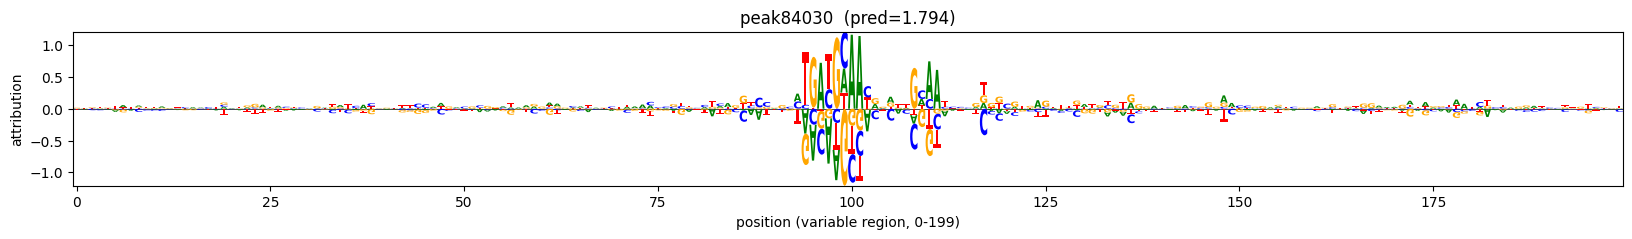

In [ ]:
## visualize wt logo
fig, ax = plt.subplots(figsize=(20, 2))
logomaker.Logo(pd.DataFrame(wt_attr, columns=list("ACGT")), ax=ax)
ax.set_xlabel("position (variable region, 0-199)")
ax.set_ylabel("attribution")
ax.set_title(f"{peak}  (pred={predictions[0]:.3f})")
plt.show()

In [ ]:
# flatten: each 4xL attribution map -> one observation in R^D, D=4L
X = attributions.reshape(attributions.shape[0], -1)   # (N, 4L)
N, D = X.shape
print(f"N={N:,}  D={D}  (=4*{D//4})")

def log_gauss_diag(X, mu, log_var):
    # diagonal-Gaussian log-density via expanded mahalanobis (no (N,K,D) intermediate)
    precision = np.exp(-log_var)                              # (K, D)
    log_norm  = -0.5 * (np.log(2*np.pi) + log_var).sum(-1)    # (K,)
    mahal     = (X**2 @ precision.T
                 - 2 * X @ (mu * precision).T
                 + (mu**2 * precision).sum(-1))               # (N, K)
    return log_norm - 0.5 * mahal

N=200,000  D=800  (=4*200)


In [ ]:
# init: K foreground Gaussians (deviations) + one shared background Gaussian (no mixing weight)
K = 100
rng = np.random.default_rng(0)

var0       = X.var(0).mean() + 1e-8
mu_bg      = X.mean(0)                                            # background mean (shared by all seqs)
mu_fg      = X[rng.choice(N, K, replace=False)] - mu_bg          # foreground deviations: mu_fg+mu_bg = data pts
log_var_fg = np.full((K, D), np.log(var0))                       # per-cluster foreground covariance Sigma_k
log_var_bg = np.full(D, np.log(1 * var0))                        # background covariance Sigma_b (broad, isotropic) changed to 1***
log_pi     = np.log(np.full(K, 1/K))                             # pi_k sum to 1 (no pi_b)

converged in 200 iters  |  final log-lik: 313264788.700  |  saved -> /grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/gmm_fits/peak84030.200k.K150.seed0.npz


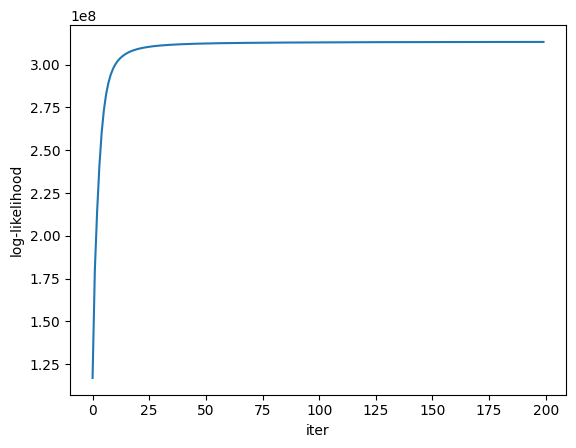

In [ ]:
# EM for x = f + b  (K foreground Gaussians convolved with one shared background; bg gets no assignments)
# cached by params: re-runs only if no fit exists for this (peak, lib, K, seed)
import os
gmm_dir  = f"{seam_dir}/gmm_fits"
os.makedirs(gmm_dir, exist_ok=True)
gmm_path = f"{gmm_dir}/{peak}.{lib}.K{K}.seed0.npz"

if os.path.exists(gmm_path):
    d = np.load(gmm_path)
    mu_fg, mu_bg     = d["mu_fg"], d["mu_bg"]
    log_var_fg, log_var_bg, log_pi = d["log_var_fg"], d["log_var_bg"], d["log_pi"]
    Nk, log_r, lls   = d["Nk"], d["log_r"], d["lls"]
    print(f"loaded cached GMM fit: {gmm_path}  ({len(lls)} iters, final log-lik {lls[-1]:.3f})")
else:
    lls = []
    for it in range(200):
        # --- E-step: responsibilities over the K foreground clusters only ---
        nu     = mu_fg + mu_bg                                          # (K,D) effective component means
        log_V  = np.log(np.exp(log_var_fg) + np.exp(log_var_bg))        # (K,D) effective cov Sigma_k+Sigma_b
        log_un = log_gauss_diag(X, nu, log_V) + log_pi                  # (N,K)
        log_r  = log_un - logsumexp(log_un, axis=1, keepdims=True)
        r      = np.exp(log_r)
        lls.append(logsumexp(log_un, axis=1).sum())                     # data log-likelihood

        # --- sufficient statistics (same shapes as a plain GMM) ---
        Nk   = r.sum(0)                                                 # (K,)
        xbar = (r.T @ X)      / Nk[:, None]                             # (K,D)
        Ex2  = (r.T @ (X**2)) / Nk[:, None]                             # (K,D)

        # --- background posterior split  b | x,k ~ N(m_ik, S_k);  all closed form in suff. stats ---
        a   = np.exp(-log_var_fg)                                       # (K,D) foreground precision 1/Sigma_k
        c   = np.exp(-log_var_bg)                                       # (D,)  background precision 1/Sigma_b
        S   = 1.0 / (a + c)                                             # (K,D) posterior var of the f/b split
        Skc, Ska = S * c, S * a                                         # (K,D)
        sm  = np.maximum(Ex2 - 2*nu*xbar + nu**2, 0.0)                  # (K,D) weighted E[(x-nu)^2]

        # --- M-step ---
        log_pi   = np.log(Nk / N)                                       # pi_k sum to 1
        mu_fg_n  = Skc * (xbar - mu_bg) + Ska * mu_fg                   # foreground means
        mu_bg_n  = (Nk[:, None] * (Ska * (xbar - mu_fg) + Skc * mu_bg)).sum(0) / N   # shared bg mean
        var_fg   = Skc**2 * sm + S                                      # Sigma_k
        var_bg   = (Nk[:, None] * (Ska**2 * sm + S)).sum(0) / N         # Sigma_b
        var_bg   = np.full(D, var_bg.mean())                           # keep bg broad/isotropic

        mu_fg, mu_bg = mu_fg_n, mu_bg_n
        log_var_fg = np.log(np.maximum(var_fg, 1e-8))
        log_var_bg = np.log(np.maximum(var_bg, 1e-8))

        if it > 0 and abs(lls[-1] - lls[-2]) < 1e-3:
            break

    np.savez_compressed(gmm_path, peak=peak, lib=lib, K=K, seed=0, n_iter=len(lls),
                        mu_fg=mu_fg, mu_bg=mu_bg, log_var_fg=log_var_fg, log_var_bg=log_var_bg,
                        log_pi=log_pi, Nk=Nk, log_r=log_r, lls=np.array(lls))
    print(f"converged in {len(lls)} iters  |  final log-lik: {lls[-1]:.3f}  |  saved -> {gmm_path}")

plt.plot(lls); plt.xlabel("iter"); plt.ylabel("log-likelihood"); plt.show()

In [ ]:
## cluster occupancy check (K foreground clusters; the background is shared and gets NO assignments)
hard = log_r.argmax(1)
pd.DataFrame({
    "Nk_soft": Nk.round(1),
    "Nk_hard": np.bincount(hard, minlength=K),
    "pi":      np.exp(log_pi).round(3),
}).sort_values("Nk_soft", ascending=False)

,Nk_soft,Nk_hard,pi
65,2282.2,2283,0.011
145,2278.1,2280,0.011
28,2074.9,2075,0.010
66,2069.8,2069,0.010
73,2042.9,2041,0.010
...,...,...,...
44,2.0,2,0.000
14,1.0,1,0.000
1,1.0,1,0.000
85,1.0,1,0.000


In [ ]:
## per-cluster foreground mean logos (largest first), shared background row last
fg_maps = mu_fg.reshape(K, D // 4, 4)         # (K, L, 4) foreground deviations mu_k
bg_map  = mu_bg.reshape(D // 4, 4)            # (L, 4) shared background mean mu_b
order   = np.argsort(-Nk)                      # clusters, largest first

fig, axes = plt.subplots(K+1, 1, figsize=(20, 1.6*(K+1)), sharex=True)
for ax, k in zip(axes[:-1], order):
    logomaker.Logo(pd.DataFrame(fg_maps[k], columns=list("ACGT")), ax=ax)
    ax.set_ylabel(f"k={k}\nn={int(Nk[k])}")
logomaker.Logo(pd.DataFrame(bg_map, columns=list("ACGT")), ax=axes[-1])
axes[-1].set_ylabel("bg\n(shared)")
axes[-1].set_xlabel("position")
fig.suptitle(f"foreground means mu_k + shared background mu_b  |  K={K}  |  {peak}")
plt.tight_layout(); plt.show()

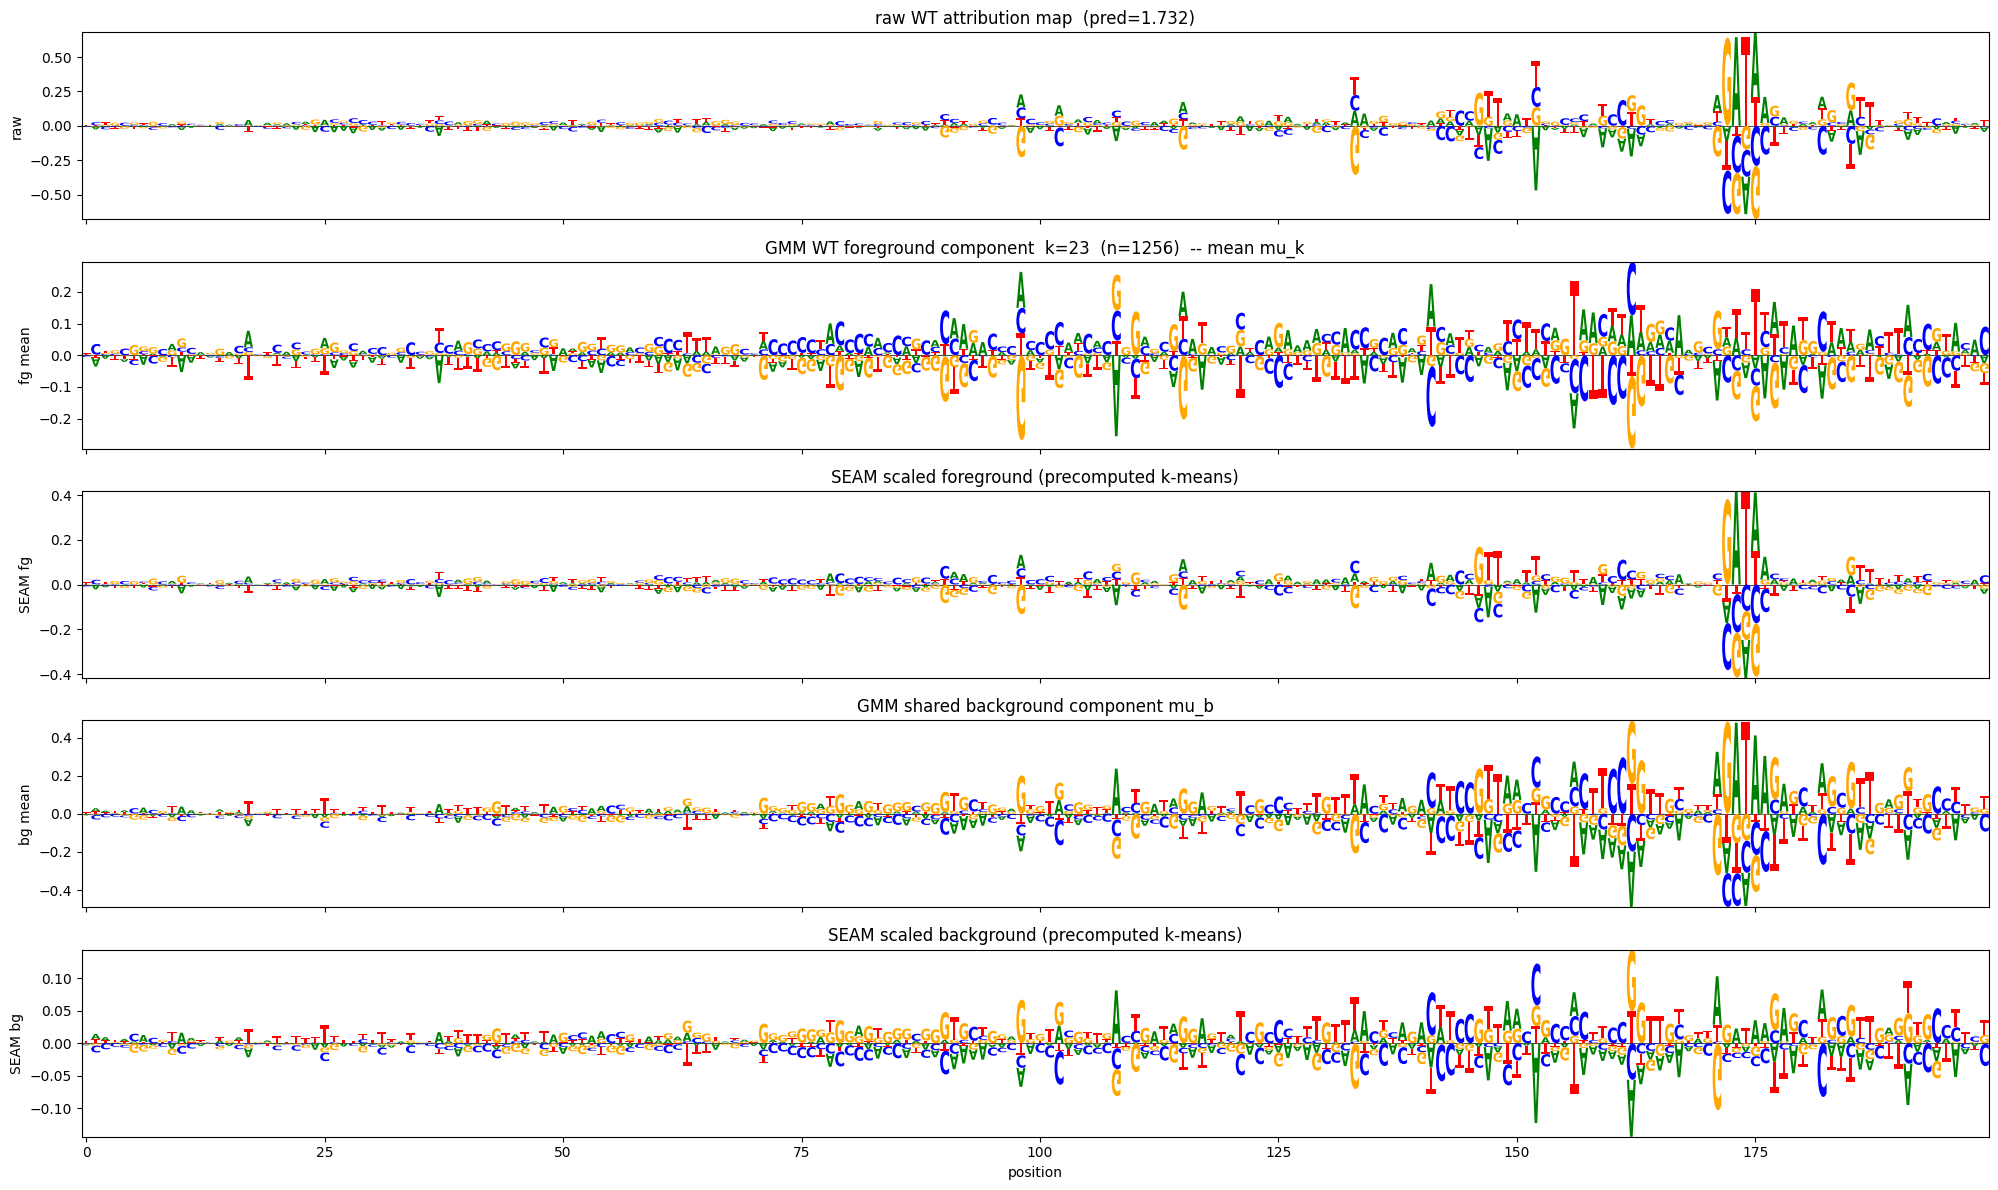

In [ ]:
# hard-assigned WT component vs SEAM: raw map, GMM fg/bg, SEAM scaled fg/bg
k_wt = hard[0]                                                 # cluster the WT map (index 0) is hard-assigned to

raw_map = wt_attr                                             # (L,4) raw WT attribution map
fg_mean = mu_fg[k_wt].reshape(D // 4, 4)                       # GMM foreground component mean mu_k  (L,4)
bg_mean = mu_bg.reshape(D // 4, 4)                             # GMM shared background mean mu_b  (L,4)

seam_dir_pk = f"{seam_dir}/foregrounds{suffix}/{peak}"
seam_fg = np.load(f"{seam_dir_pk}/foreground_scaled.npy")            # SEAM scaled foreground (ref/WT cluster)
seam_bg = np.load(f"{seam_dir_pk}/average_background_scaled.npy")    # SEAM scaled background (ref/WT cluster)

panels = [
    (raw_map, "raw",        f"raw WT attribution map  (pred={predictions[0]:.3f})"),
    (fg_mean, "fg mean",    f"GMM WT foreground component  k={k_wt}  (n={int(Nk[k_wt])})  -- mean mu_k"),
    (seam_fg, "SEAM fg",    "SEAM scaled foreground (precomputed k-means)"),
    (bg_mean, "bg mean",    "GMM shared background component mu_b"),
    (seam_bg, "SEAM bg",    "SEAM scaled background (precomputed k-means)"),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(20, 2.4*len(panels)), sharex=True)
for ax, (m, ylab, title) in zip(axes, panels):
    logomaker.Logo(pd.DataFrame(m, columns=list("ACGT")), ax=ax)
    ax.set_ylabel(ylab)
    ax.set_title(title)
axes[-1].set_xlabel("position")
plt.tight_layout(); plt.show()

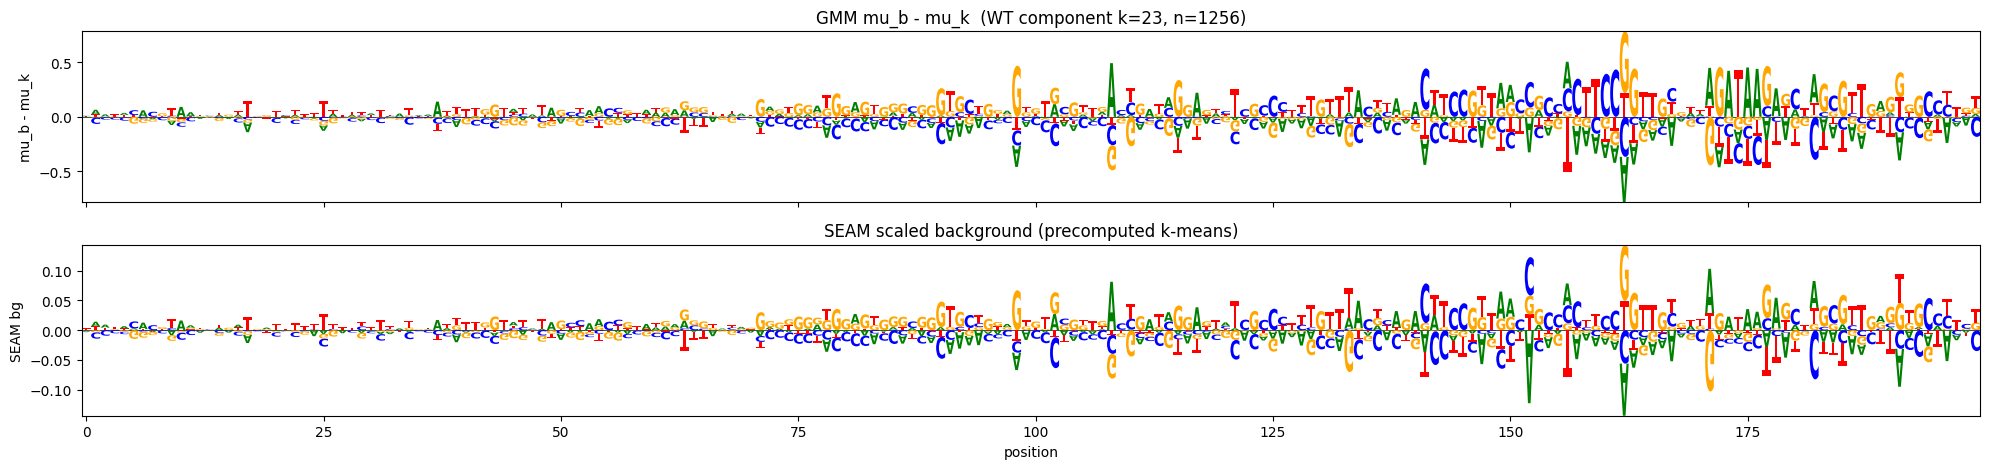

In [ ]:
## mu_bg - mu_k (WT component) vs SEAM scaled background
diff_map = (mu_bg - mu_fg[k_wt]).reshape(D // 4, 4)

panels = [
    (diff_map, "mu_b - mu_k", f"GMM mu_b - mu_k  (WT component k={k_wt}, n={int(Nk[k_wt])})"),
    (seam_bg,  "SEAM bg",     "SEAM scaled background (precomputed k-means)"),
]
fig, axes = plt.subplots(len(panels), 1, figsize=(20, 2.4*len(panels)), sharex=True)
for ax, (m, ylab, title) in zip(axes, panels):
    logomaker.Logo(pd.DataFrame(m, columns=list("ACGT")), ax=ax)
    ax.set_ylabel(ylab); ax.set_title(title)
axes[-1].set_xlabel("position")
plt.tight_layout(); plt.show()

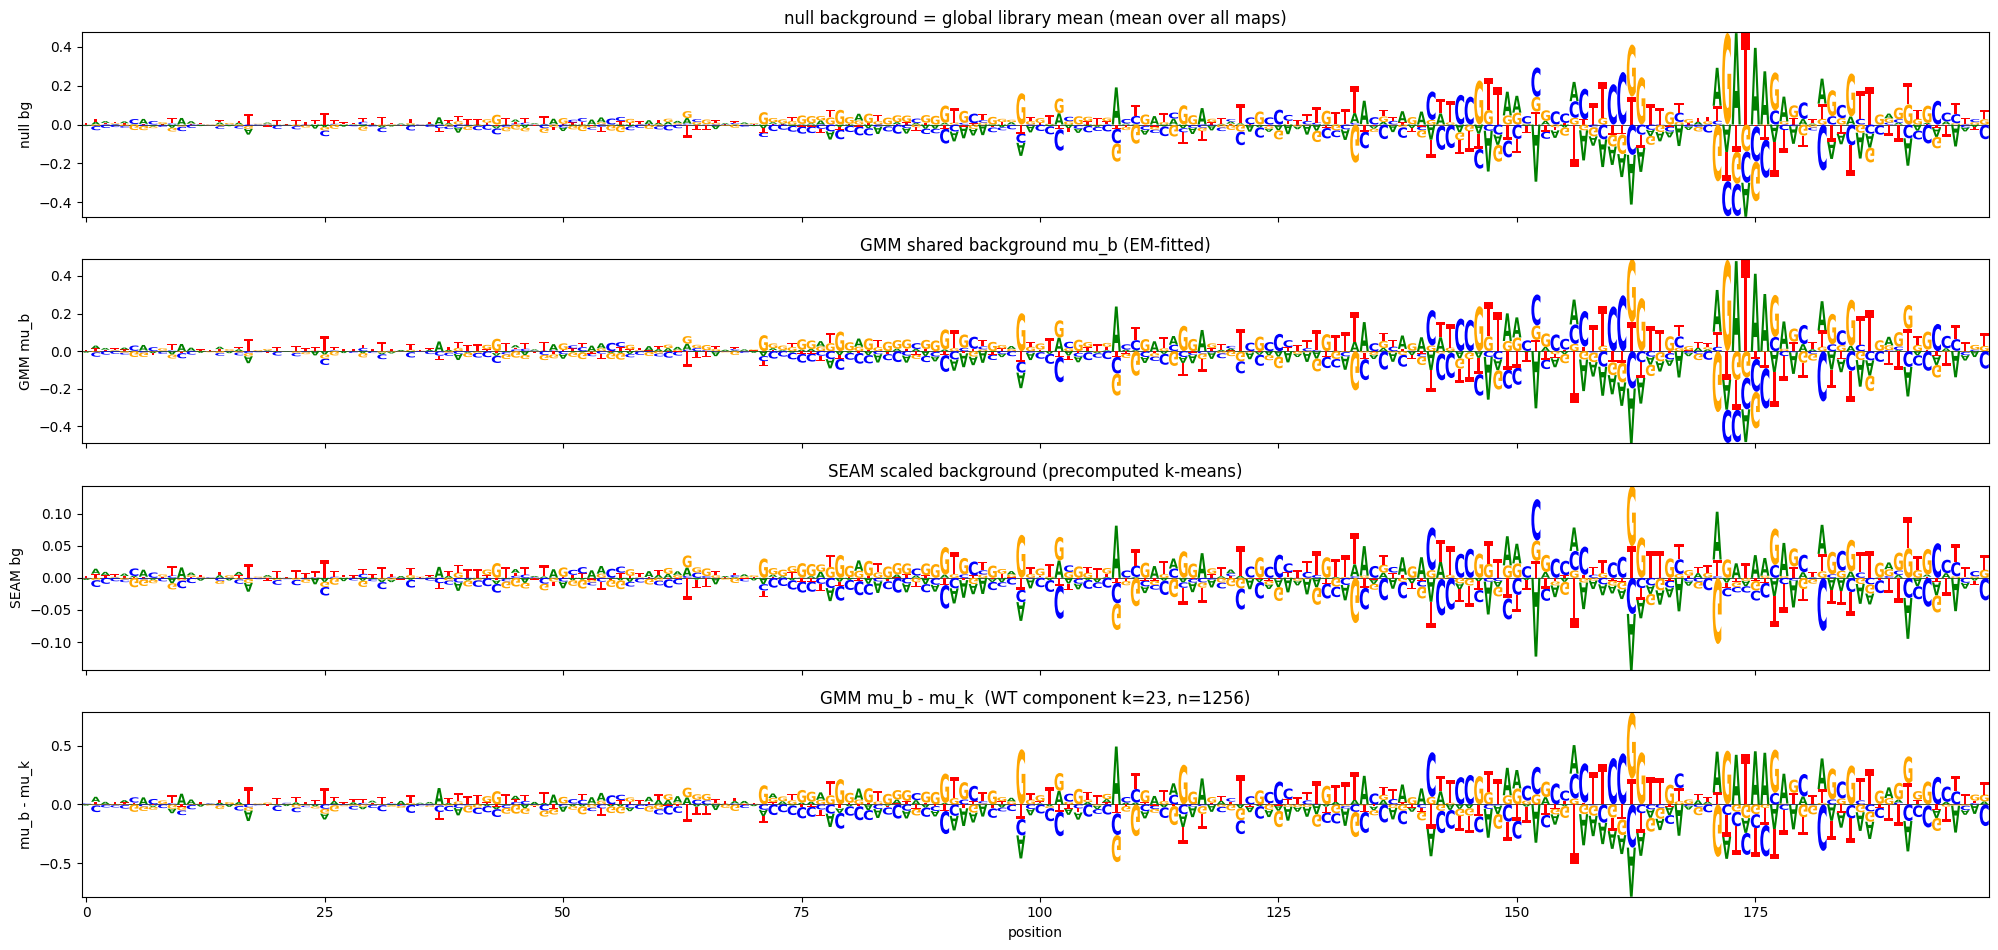

In [ ]:
## null background = global library mean, vs GMM mu_b, SEAM bg, and mu_b - mu_k
null_bg = X.mean(0).reshape(D // 4, 4)
gmm_bg  = mu_bg.reshape(D // 4, 4)
diff_map = (mu_bg - mu_fg[k_wt]).reshape(D // 4, 4)

panels = [
    (null_bg,  "null bg",     "null background = global library mean (mean over all maps)"),
    (gmm_bg,   "GMM mu_b",    "GMM shared background mu_b (EM-fitted)"),
    (seam_bg,  "SEAM bg",     "SEAM scaled background (precomputed k-means)"),
    (diff_map, "mu_b - mu_k", f"GMM mu_b - mu_k  (WT component k={k_wt}, n={int(Nk[k_wt])})"),
]
fig, axes = plt.subplots(len(panels), 1, figsize=(20, 2.4*len(panels)), sharex=True)
for ax, (m, ylab, title) in zip(axes, panels):
    logomaker.Logo(pd.DataFrame(m, columns=list("ACGT")), ax=ax)
    ax.set_ylabel(ylab); ax.set_title(title)
axes[-1].set_xlabel("position")
plt.tight_layout(); plt.show()